In [ ]:
"""
DEEP EDA & FEATURE ENGINEERING PIPELINE

Mục tiêu:
- Khám phá dữ liệu để tìm ra các pattern gây trễ giao hàng
- Chuyển insight từ EDA thành feature engineering có ý nghĩa

Chiến lược:
1. Chỉ sử dụng tập A (Apr-Jun) để EDA nhằm tránh data leakage từ tương lai
2. Phân tích:
   - Class imbalance → định hướng metric & modeling strategy
   - Lead time → xử lý outliers dựa trên domain knowledge
   - Sparse categorical → giảm chiều & chống overfitting
   - Feature interactions → tìm micro-segments gây delay
3. Xây dựng pipeline Feature Engineering:
   - Time-based features
   - Lead time capping [0, 90]
   - Rare entity grouping + frequency encoding
   - Feature crossing (interaction features)

Output:
- dataset_A_fe.parquet (train)
- dataset_B_fe.parquet (test - out-of-time)

Note:
- Pipeline tuân thủ nguyên tắc fit trên train, transform trên test
- Tránh hoàn toàn data leakage
"""

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Cấu hình biểu đồ chuyên nghiệp
%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")

In [3]:
processed_dir = r'D:\Ds108\Lab4\processed_data'

# Chỉ dùng Tập A (Tháng 4-6) để làm EDA nhằm tránh Data Leakage từ tương lai (Tập B)
df_A = pd.read_parquet(f'{processed_dir}\\dataset_A_tidy.parquet')
df_B = pd.read_parquet(f'{processed_dir}\\dataset_B_tidy.parquet')

# Tiền tính toán Lead Time cho EDA
df_A['planned_lead_time'] = (df_A['VSD'] - df_A['Order_date']).dt.days
df_B['planned_lead_time'] = (df_B['VSD'] - df_B['Order_date']).dt.days

print("Load data thanh cong!")
print(f"Tap A (EDA & Fit): {df_A.shape}")
print(f"Tap B (Transform): {df_B.shape}")

Load data thanh cong!
Tap A (EDA & Fit): (399053, 29)
Tap B (Transform): (1074897, 29)


------------------------------------------------------------
[1] CLASS IMBALANCE DETECTOR
------------------------------------------------------------


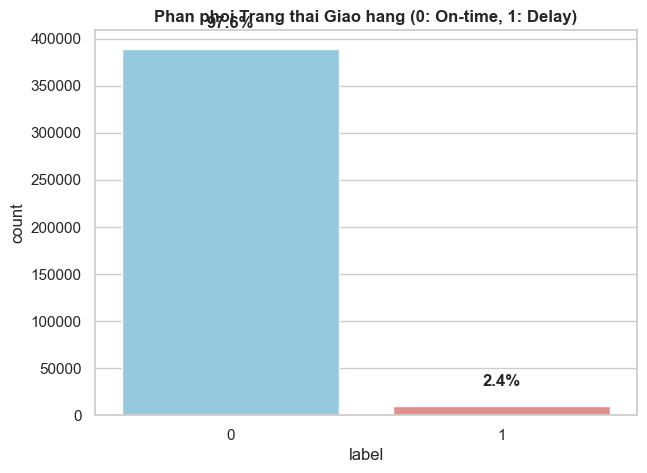

So don dung han : 389320
So don tre han  : 9733
==> Kết luận: Lớp đa số gấp 40.0 lần lớp thiểu số.
==> VAI TRO: Chung minh data bi Extreme Imbalance. Vo hieu hoa Accuracy, bat buoc dung Macro F1 va setup tham so scale_pos_weight trong mo hinh.
==> VAI TRÒ: Chứng minh data bị Extreme Imbalance. Vô hiệu hóa Accuracy, bắt buộc dùng Macro F1 va setup tham số scale_pos_weight trong mô hình.


In [4]:
# -----------------------------------------------------------
# 1. PHÂN TÍCH ĐƠN BIẾN: CLASS IMBALANCE (Sai lệch phân phối nhãn)
# -----------------------------------------------------------
def detect_class_imbalance(df):
    print("-" * 60)
    print("[1] CLASS IMBALANCE DETECTOR")
    print("-" * 60)
    
    plt.figure(figsize=(7, 5))
    ax = sns.countplot(data=df, x='label', palette=['skyblue', 'lightcoral'])
    plt.title("Phan phoi Trang thai Giao hang (0: On-time, 1: Delay)", fontweight='bold')
    
    total = len(df)
    for p in ax.patches:
        percentage = f'{100 * p.get_height() / total:.1f}%\n'
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax.annotate(percentage, (x, y), ha='center', va='bottom', fontweight='bold')
    plt.show()
    
    delay_count = df['label'].sum()
    ontime_count = total - delay_count
    ratio = ontime_count / delay_count
    
    print(f"So don dung han : {ontime_count}")
    print(f"So don tre han  : {delay_count}")
    print(f"==> Kết luận: Lớp đa số gấp {ratio:.1f} lần lớp thiểu số.")
    print("==> VAI TRO: Chung minh data bi Extreme Imbalance. Vo hieu hoa Accuracy, bat buoc dung Macro F1 va setup tham so scale_pos_weight trong mo hinh.")
    print("==> VAI TRÒ: Chứng minh data bị Extreme Imbalance. Vô hiệu hóa Accuracy, bắt buộc dùng Macro F1 va setup tham số scale_pos_weight trong mô hình.")
detect_class_imbalance(df_A)

------------------------------------------------------------
[2] DOMAIN LOGIC: PLANNED LEAD TIME OUTLIERS
------------------------------------------------------------
VẤN ĐỀ: Thống kê IQR sẽ xóa nhầm các đơn dự án (Lead time > 40 ngày).
- Phát hiện 0 đơn có Lead Time âm (VSD < Order_date -> Lỗi Data Entry).
- Phát hiện 19897 đơn có Lead Time > 90 ngày (Hợp lệ trong Supply Chain).


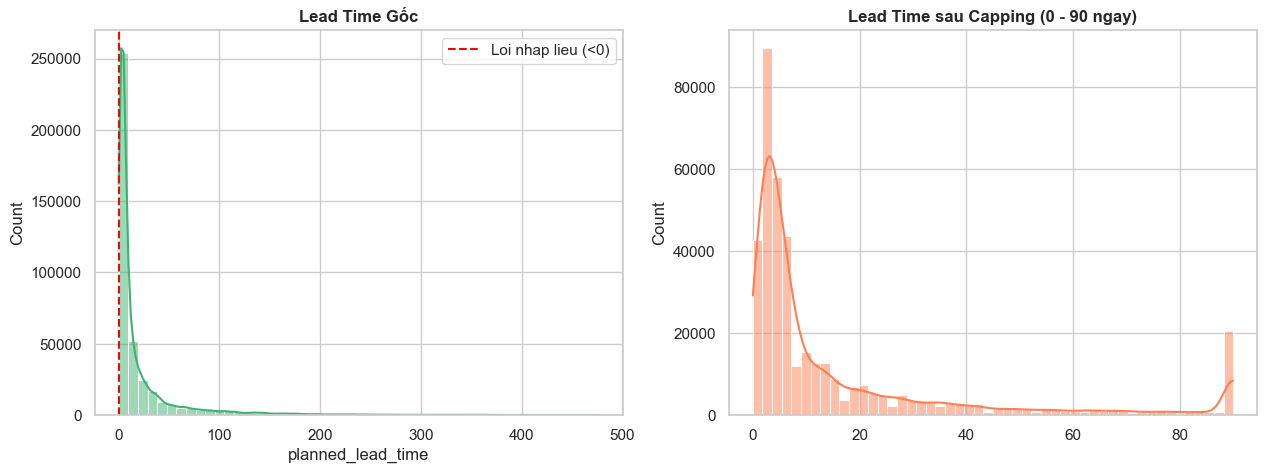

==> GIẢI PHÁP: Capping bằng Domain Knowledge [0, 90] thay vì IQR để không làm mất hành vi đặt hàng dài hạn.


In [5]:
# -----------------------------------------------------------
# 2. PHÂN TÍCH ĐƠN BIẾN: TIME OUTLIERS VS DOMAIN KNOWLEDGE
# -----------------------------------------------------------
def analyze_lead_time_outliers(df):
    """
    Mục tiêu:
    - Trực quan hóa phân phối của biến thời gian chờ dự kiến (planned_lead_time).
    - Phát hiện các điểm bất hợp lý về mặt logic (như thời gian âm) và các đơn hàng dự án kéo dài.
    - So sánh phân phối trước và sau khi áp dụng kỹ thuật Capping (Windsorization).
    
    [QUAN SÁT TỪ BIỂU ĐỒ (OBSERVATION)]:
    - Hình bên trái (Gốc): Dữ liệu bị lệch phải rất nặng (Right-skewed). Có một lượng nhỏ đơn hàng nằm bên trái vạch đỏ (Lead Time < 0), đây chắc chắn là lỗi nhập liệu (Data Entry Error) vì ngày giao không thể diễn ra trước ngày đặt. Phần đuôi kéo dài qua mốc 100-200 ngày phản ánh các đơn hàng dự án (Project Orders) - điều rất bình thường trong Supply Chain.
    - Hình bên phải (Sau Capping): Phân phối trở nên gọn gàng hơn. Phần đuôi dài đã được gom lại tại mốc 90 ngày (tạo thành một cột nhô lên ở cuối).
    
    [HÀNH ĐỘNG/KẾT LUẬN]:
    - Nếu dùng IQR hay Z-Score, thuật toán sẽ nhầm tưởng các đơn hàng > 40 ngày là nhiễu và xóa đi, làm mất đi một phân khúc khách hàng quan trọng.
    - Giải pháp: Dùng Hard Threshold (0 và 90). Quy các giá trị âm về 0 và Capping các giá trị > 90 về đúng 90.
    - Tuy Lead time có long tail kéo dài > 400 ngày, nhưng vì mật độ giảm mạnh sau khoảng 90 ngày nên em chọn mốc này là điểm cân bằng thông tin và giảm nhiễu.
    """
    print("-" * 60)
    print("[2] DOMAIN LOGIC: PLANNED LEAD TIME OUTLIERS")
    print("-" * 60)
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Biểu đồ gốc
    sns.histplot(df['planned_lead_time'].dropna(), bins=50, color='mediumseagreen', kde=True, ax=axes[0])
    axes[0].set_title('Lead Time Gốc', fontweight='bold')
    axes[0].axvline(0, color='red', linestyle='--', label='Loi nhap lieu (<0)')
    axes[0].legend()
    
    negative_lt = df[df['planned_lead_time'] < 0].shape[0]
    super_long_lt = df[df['planned_lead_time'] > 90].shape[0]
    
    print("VẤN ĐỀ: Thống kê IQR sẽ xóa nhầm các đơn dự án (Lead time > 40 ngày).")
    print(f"- Phát hiện {negative_lt} đơn có Lead Time âm (VSD < Order_date -> Lỗi Data Entry).")
    print(f"- Phát hiện {super_long_lt} đơn có Lead Time > 90 ngày (Hợp lệ trong Supply Chain).")
    
    # Mô phỏng Capping
    temp_lt = np.where(df['planned_lead_time'] < 0, 0, df['planned_lead_time'])
    temp_lt = np.where(temp_lt > 90, 90, temp_lt)
    
    sns.histplot(temp_lt, bins=50, color='coral', kde=True, ax=axes[1])
    axes[1].set_title('Lead Time sau Capping (0 - 90 ngay)', fontweight='bold')
    plt.show()
    
    print("==> GIẢI PHÁP: Capping bằng Domain Knowledge [0, 90] thay vì IQR để không làm mất hành vi đặt hàng dài hạn.")

analyze_lead_time_outliers(df_A)

------------------------------------------------------------
[3] SPARSE METADATA: GOM NHÓM SUPPLIER_CD HIẾM
------------------------------------------------------------


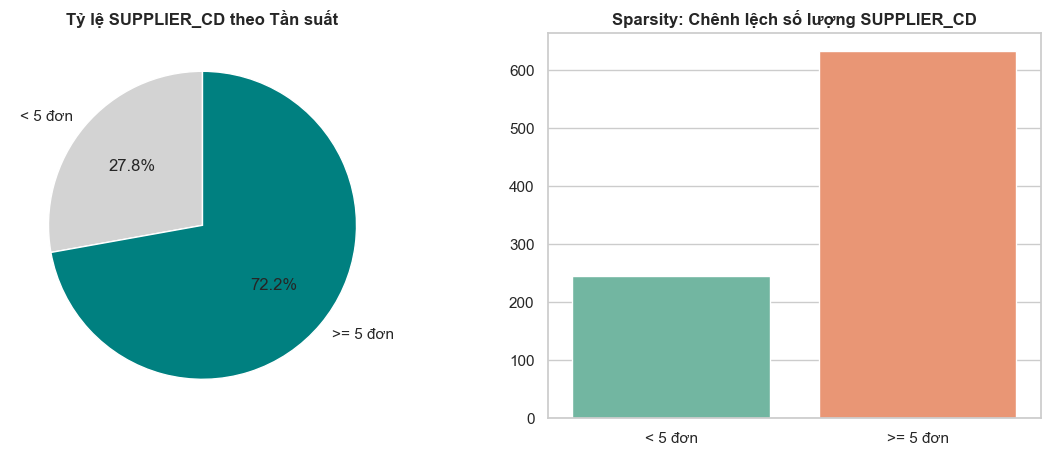

VẤN ĐỀ: Phát hiện 244 SUPPLIER_CD (chiếm 27.8%) chỉ xuất hiện dưới 5 lần.
==> GIẢI PHÁP: Gom nhóm thành 'RARE_ENTITY' để thu gọn không gian Vector, tránh Lời nguyền số chiều (Curse of Dimensionality) và chống Overfit cho Cây quyết định.


In [6]:
# -----------------------------------------------------------
# 3. PHÂN TÍCH THỰC THỂ HIẾM (DIMENSIONALITY REDUCTION)
# -----------------------------------------------------------
def analyze_sparse_metadata(df, col='SUPPLIER_CD', threshold=5):
    """
    Mục tiêu:
    - Đếm tần suất xuất hiện của từng Nhà cung cấp (SUPPLIER_CD).
    - Chia các nhà cung cấp thành 2 nhóm: "Vãng lai" (xuất hiện < 5 lần) và "Thường xuyên" (>= 5 lần).
    - Trực quan hóa tỷ trọng của nhóm vãng lai này để đánh giá mức độ phân mảnh (Sparsity) của dữ liệu.
    
    [QUAN SÁT TỪ BIỂU ĐỒ (OBSERVATION)]:
    - Mặc dù chỉ là nhóm thiểu số về lượng đơn hàng, nhưng số lượng định danh (IDs) của các nhà cung cấp vãng lai lại chiếm một tỷ lệ đáng kể (27.8% tổng số Supplier). 
    - Sự chênh lệch này (thể hiện rõ ở biểu đồ Bar chart bên phải) cho thấy hệ thống có rất nhiều đối tác chỉ hợp tác 1-2 lần rồi thôi.
    
    [HÀNH ĐỘNG/KẾT LUẬN]:
    - Nếu để nguyên các mã định danh này đưa vào mô hình Tree-based (LightGBM/XGBoost), cây quyết định sẽ phải chẻ ra vô số nhánh nhỏ vô dụng, gây tốn bộ nhớ và dẫn đến hiện tượng Overfitting (học vẹt).
    - Giải pháp: Gom tất cả các Supplier xuất hiện dưới 5 lần vào chung một nhóm có tên là 'RARE_ENTITY'. Điều này giúp thu gọn ma trận đặc trưng, ép mô hình tập trung vào việc tìm pattern của các đối tác lớn.
    """

    print("-" * 60)
    print(f"[3] SPARSE METADATA: GOM NHÓM {col} HIẾM")
    print("-" * 60)
    
    counts = df[col].value_counts()
    rare_count = counts[counts < threshold].shape[0]
    popular_count = counts[counts >= threshold].shape[0]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].pie([rare_count, popular_count], labels=[f'< {threshold} đơn', f'>= {threshold} đơn'], 
                autopct='%1.1f%%', colors=['lightgray', 'teal'], startangle=90)
    axes[0].set_title(f'Tỷ lệ {col} theo Tần suất', fontweight='bold')
    
    sns.barplot(x=[f'< {threshold} đơn', f'>= {threshold} đơn'], y=[rare_count, popular_count], ax=axes[1], palette='Set2')
    axes[1].set_title(f'Sparsity: Chênh lệch số lượng {col}', fontweight='bold')
    plt.show()
    
    print(f"VẤN ĐỀ: Phát hiện {rare_count} {col} (chiếm {rare_count/len(counts)*100:.1f}%) chỉ xuất hiện dưới {threshold} lần.")
    print("==> GIẢI PHÁP: Gom nhóm thành 'RARE_ENTITY' để thu gọn không gian Vector, tránh Lời nguyền số chiều (Curse of Dimensionality) và chống Overfit cho Cây quyết định.")

analyze_sparse_metadata(df_A, 'SUPPLIER_CD', 5)

------------------------------------------------------------
[4] BIVARIATE ANALYSIS: ĐỘ LỆCH TƯƠNG TÁC (INTERACTION BIAS)
------------------------------------------------------------


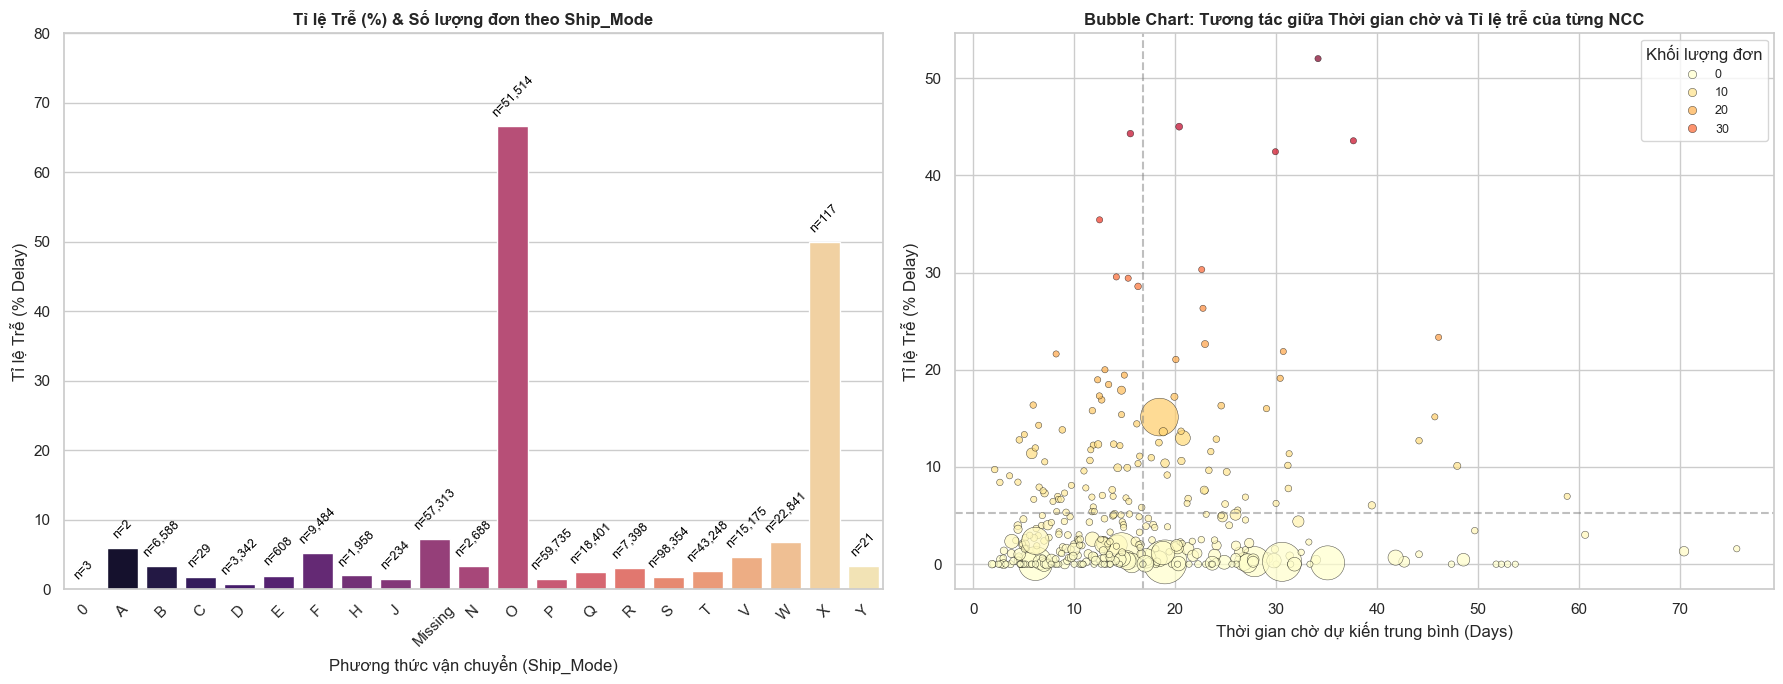

In [13]:
# -----------------------------------------------------------
# 4. PHÂN TÍCH ĐA BIẾN (TƯƠNG TÁC GÂY TRỄ HẠN)
# -----------------------------------------------------------
def analyze_bivariate_interactions(df):
    """
    [GIẢI THÍCH MỤC ĐÍCH CODE]:
    - Khám phá mối quan hệ Đa biến (Bivariate): Sự trễ hạn do tương tác kết hợp giữa các yếu tố.
    - Biểu đồ Bar: Đánh giá rủi ro của từng Ship_Mode kèm theo khối lượng thực tế.
    - Biểu đồ Bubble Scatter: Phân tích sự phân hóa rủi ro của các Nhà cung cấp dựa trên Thời gian chờ trung bình và Khối lượng đơn hàng.

    [QUAN SÁT TỪ BIỂU ĐỒ (OBSERVATION)]:
    - Biểu đồ Bar (Trái): Phương thức 'O' có tỉ lệ trễ cao nhất nhưng số lượng cực ít (n=2), trong khi đó các phương thức khác có phân phối trễ rõ ràng hơn.
    - Biểu đồ Bubble (Phải): Mỗi chấm tròn là 1 Nhà cung cấp. 
        + Trục X là độ kéo dài của đơn hàng, Trục Y là mức độ rủi ro trễ hẹn.
        + Kích thước bóng to hay nhỏ phản ánh khối lượng đơn hàng họ đảm nhận.
        + Ta có thể dễ dàng khoanh vùng "Vùng an toàn" (Góc dưới bên trái - Nhanh & Ít trễ) và "Vùng rủi ro cao" (Góc trên). Sự phân tán này chứng tỏ Lead Time có tác động mạnh nhưng không đồng đều lên các Supplier khác nhau.

    [HÀNH ĐỘNG/KẾT LUẬN]:
    - Chứng minh dữ liệu có tính chất phi tuyến tính và tương tác phức tạp. Bắt buộc phải dùng Feature Crossing (Ghép chéo biến) và các thuật toán Tree-based thay vì Linear Model.
    """
    print("-" * 60)
    print("[4] BIVARIATE ANALYSIS: ĐỘ LỆCH TƯƠNG TÁC (INTERACTION BIAS)")
    print("-" * 60)
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    
    # ---------------------------------------------------------
    # 4.1 Ship Mode vs Delay (Bar Chart)
    # ---------------------------------------------------------
    if 'Ship_Mode' in df.columns:
        ship_stats = df.groupby('Ship_Mode')['label'].agg(['mean', 'count']).reset_index()
        ship_stats['mean'] = ship_stats['mean'] * 100
        ship_stats = ship_stats.sort_values(by='mean', ascending=False)
        
        ax1 = sns.barplot(data=ship_stats, x='Ship_Mode', y='mean', palette='magma', ax=axes[0])
        axes[0].set_title('Tỉ lệ Trễ (%) & Số lượng đơn theo Ship_Mode', fontweight='bold', fontsize=12)
        axes[0].set_ylabel('Tỉ lệ Trễ (% Delay)')
        axes[0].set_xlabel('Phương thức vận chuyển (Ship_Mode)')
        axes[0].tick_params(axis='x', rotation=45)
        
        for p, count in zip(ax1.patches, ship_stats['count']):
            ax1.annotate(f'n={int(count):,}', 
                         (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha='center', va='bottom', fontsize=9, color='black', 
                         xytext=(0, 5), textcoords='offset points', rotation=45)
        axes[0].set_ylim(0, ship_stats['mean'].max() * 1.2)

    # ---------------------------------------------------------
    # 4.2 Bubble Scatter Plot: NCC vs Thời gian vs Rủi ro
    # ---------------------------------------------------------
    # Gom nhóm theo Nhà cung cấp
    supp_stats = df.groupby('SUPPLIER_CD').agg(
        delay_rate=('label', lambda x: x.mean() * 100),
        avg_lead_time=('planned_lead_time', 'mean'),
        total_orders=('label', 'count')
    ).reset_index()
    
    # Lọc nhiễu: Chỉ lấy những NCC có >= 30 đơn hàng để biểu đồ không bị rác bởi các điểm 100% trễ ảo
    supp_stats = supp_stats[supp_stats['total_orders'] >= 30]
    
    # Vẽ Scatter Plot
    scatter = sns.scatterplot(
        data=supp_stats,
        x='avg_lead_time',
        y='delay_rate',
        size='total_orders',      # Kích thước = Tổng đơn
        hue='delay_rate',         # Màu sắc = Tỉ lệ trễ (càng đỏ càng nguy hiểm)
        sizes=(20, 1000),         # Chỉnh độ thu phóng của bong bóng
        palette='YlOrRd',
        alpha=0.7,                # Độ trong suốt để thấy các điểm chồng lên nhau
        edgecolor='black',        # Viền đen cho dễ nhìn
        ax=axes[1]
    )
    
    axes[1].set_title('Bubble Chart: Tương tác giữa Thời gian chờ và Tỉ lệ trễ của từng NCC', fontweight='bold', fontsize=12)
    axes[1].set_xlabel('Thời gian chờ dự kiến trung bình (Days)')
    axes[1].set_ylabel('Tỉ lệ Trễ (% Delay)')
    
    # Kẻ vạch tham chiếu trung bình
    mean_delay = supp_stats['delay_rate'].mean()
    mean_lt = supp_stats['avg_lead_time'].mean()
    axes[1].axhline(mean_delay, color='gray', linestyle='--', alpha=0.5)
    axes[1].axvline(mean_lt, color='gray', linestyle='--', alpha=0.5)
    
    # Tùy chỉnh Legend cho gọn gàng (không bị che đồ thị)
    handles, labels = scatter.get_legend_handles_labels()
    axes[1].legend(handles=handles[1:5], labels=labels[1:5], 
                   title="Khối lượng đơn", loc='upper right', fontsize=9)
    
    plt.tight_layout()
    plt.show()

analyze_bivariate_interactions(df_A)

In [ ]:
"""
Feature engineering pipeline được thiết kế dựa trên các insight từ EDA:

1. Time-based features:
   - Trích xuất thông tin thời gian để capture seasonality và weekly patterns

2. Lead time engineering:
   - Tạo biến planned_lead_time phản ánh độ gấp của đơn hàng
   - Áp dụng capping để giảm ảnh hưởng của extreme values

3. High-cardinality handling:
   - Gom nhóm entity hiếm thành 'RARE'
   - Sử dụng frequency encoding để biểu diễn độ phổ biến

4. Feature crossing:
   - Tạo các biến tương tác để mô hình học được các micro-segments

5. Leakage prevention:
   - Toàn bộ thống kê được học trên train và áp dụng cho test

"""

In [8]:
# -----------------------------------------------------------
# 5. FEATURE ENGINEERING PIPELINE (Áp dụng các giải pháp từ EDA)
# -----------------------------------------------------------
def feature_engineering_pipeline(df_train, df_test=None):
    """
    Fit trên tập Train (A) và Transform trên tập Test (B) để chống Data Leakage.
    """
    def transform_df(df, is_train=False, stats=None):
        d = df.copy()
        
        # 1. TIME FEATURES (Vectorized)
        d['order_month'] = d['Order_date'].dt.month
        d['order_dayofweek'] = d['Order_date'].dt.dayofweek
        d['order_is_weekend'] = d['order_dayofweek'].isin([5, 6]).astype(int)
        
        d['vsd_month'] = d['VSD'].dt.month
        d['vsd_is_weekend'] = d['VSD'].dt.dayofweek.isin([5, 6]).astype(int)
        
        # Capping Lead Time theo Domain Knowledge
        d['planned_lead_time'] = (d['VSD'] - d['Order_date']).dt.days
        d['planned_lead_time'] = np.where(d['planned_lead_time'] < 0, 0, d['planned_lead_time'])
        d['planned_lead_time'] = np.where(d['planned_lead_time'] > 90, 90, d['planned_lead_time'])
        d['planned_lead_time'] = d['planned_lead_time'].fillna(0)
        
        # 2. RARE ENTITY HANDLING & FREQUENCY ENCODING
        high_card_cols = ['SUPPLIER_CD', 'PRODUCT_CD', 'BRAND_CD']
        
        # Chỉ học phân phối trên tập Train
        if is_train:
            stats = {'freq': {}, 'rare': {}}
            for col in high_card_cols:
                counts = d[col].value_counts()
                stats['freq'][col] = counts.to_dict()
                stats['rare'][col] = set(counts[counts < 5].index.tolist()) # Set lookup nhanh
                
        # Áp dụng cho cả Train và Test (Nằm NGOÀI if is_train)
        for col in high_card_cols:
            # FIX LỖI CATEGORY TẠI ĐÂY
            if 'RARE' not in d[col].cat.categories:
                d[col] = d[col].cat.add_categories(['RARE'])
                
            # TỐI ƯU SIÊU TỐC: Dùng mask và isin
            d[col] = d[col].mask(d[col].isin(stats['rare'][col]), 'RARE')
            d[f'{col}_freq_count'] = d[col].map(stats['freq'][col]).fillna(0)
            
        # 3. FEATURE CROSSING
        d['Supplier_cross_Brand'] = d['SUPPLIER_CD'].astype(str) + "_" + d['BRAND_CD'].astype(str)
        d['Supplier_cross_Brand'] = d['Supplier_cross_Brand'].astype('category')
        
        d['ShipMode_cross_Weekend'] = d['Ship_Mode'].astype(str) + "_" + d['vsd_is_weekend'].astype(str)
        d['ShipMode_cross_Weekend'] = d['ShipMode_cross_Weekend'].astype('category')
        
        # 4. DỌN DẸP DATETIME
        d = d.drop(columns=['Order_date', 'VSD'])
        
        return d, stats

    # ========================================================
    # THỰC THI PIPELINE
    # ========================================================
    print("Engineering tap Train (A)...")
    train_fe, learned_stats = transform_df(df_train, is_train=True)
    
    if df_test is not None:
        print("Engineering tap Test (B)...")
        test_fe, _ = transform_df(df_test, is_train=False, stats=learned_stats)
        return train_fe, test_fe
        
    return train_fe

# Gọi hàm
df_A_fe, df_B_fe = feature_engineering_pipeline(df_A, df_B)

# Lưu dữ liệu
fe_dir = r'D:\Ds108\Lab4\processed_data'
import os
if not os.path.exists(fe_dir):
    os.makedirs(fe_dir)
    
df_A_fe.to_parquet(f'{fe_dir}\\dataset_A_fe.parquet', index=False)
df_B_fe.to_parquet(f'{fe_dir}\\dataset_B_fe.parquet', index=False)

print("\n=> [Hoan Thanh] Notebook 2: Deep EDA & FE da xong. San sang tien vao Modeling (Notebook 3)!")

Engineering tap Train (A)...
Engineering tap Test (B)...

=> [Hoan Thanh] Notebook 2: Deep EDA & FE da xong. San sang tien vao Modeling (Notebook 3)!
